<a href="https://colab.research.google.com/github/germanRM11/PTY-IQ/blob/main/PTY_IQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# =============================================================================
# PTY-IQ — Sistema de Predicción de Retrasos de Vuelos
# Autor  : German Granados
# Fecha  : Febrero 2026
# Versión: 1.0
# =============================================================================
# Descripción:
#   Sistema de inteligencia artificial para anticipar retrasos de vuelos
#   en el Aeropuerto Internacional de Tocumen (PTY), Panamá.
#   Combina datos históricos del BTS con telemetría en tiempo real de
#   OpenSky Network para generar alertas operacionales con 30-90 min
#   de anticipación.
# =============================================================================

In [17]:
!pip install xgboost folium --quiet

import glob
import os
import pickle
import shutil
import urllib.request
import warnings
import zipfile
from datetime import datetime

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
print("Dependencias cargadas correctamente.")


Dependencias cargadas correctamente.


In [18]:
# Fuente: Bureau of Transportation Statistics — On-Time Performance 2024

URL_BTS = "https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2024_1.zip"

print("Descargando datos históricos...")
urllib.request.urlretrieve(URL_BTS, "vuelos_2024_01.zip")

with zipfile.ZipFile("vuelos_2024_01.zip", 'r') as z:
    z.extractall("datos_bts")

archivo_csv = glob.glob("datos_bts/*.csv")[0]
df_raw = pd.read_csv(archivo_csv, low_memory=False)

print(f"Dataset cargado: {df_raw.shape[0]:,} vuelos, {df_raw.shape[1]} columnas.")

Descargando datos históricos...
Dataset cargado: 547,271 vuelos, 110 columnas.


In [19]:
# Calcular hora de salida como entero (ej: 1430 → 14)
df_raw['DEP_HOUR'] = (df_raw['DepTime'] // 100).astype('Int64')

COLUMNAS = {
    'Reporting_Airline': 'AEROLINEA',
    'Origin':            'ORIGEN',
    'Dest':              'DESTINO',
    'DepDelay':          'RETRASO_SALIDA',
    'ArrDelay':          'RETRASO_LLEGADA',
    'AirTime':           'DURACION_VUELO',
    'Distance':          'DISTANCIA',
    'DayOfWeek':         'DIA_SEMANA',
    'Month':             'MES',
    'DEP_HOUR':          'HORA_SALIDA',
    'Cancelled':         'CANCELADO',
}

df = df_raw[list(COLUMNAS.keys())].rename(columns=COLUMNAS).copy()

# Eliminar cancelados e incompletos
df = df[df['CANCELADO'] == 0]
df = df.dropna(subset=['RETRASO_LLEGADA', 'RETRASO_SALIDA', 'DURACION_VUELO'])
df = df.drop(columns=['CANCELADO']).reset_index(drop=True)

# Variable objetivo: retraso > 15 min (estándar IATA)
df['RETRASADO'] = (df['RETRASO_LLEGADA'] > 15).astype(int)

total     = len(df)
retrasados = df['RETRASADO'].sum()
print(f"Dataset limpio: {total:,} vuelos | {retrasados/total*100:.1f}% retrasados.")

Dataset limpio: 525,370 vuelos | 23.3% retrasados.


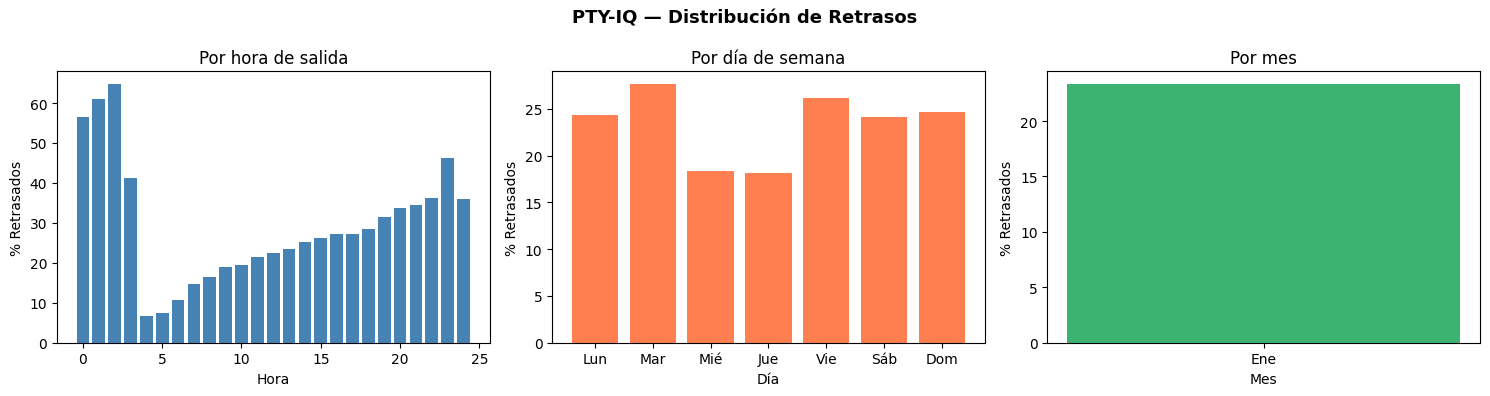

Hora pico de retrasos  : 2:00 (64.7%)
Hora más puntual       : 4:00 (6.8%)
Día más retrasado      : Mar (27.6%)
Día más puntual        : Jue (18.2%)


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('PTY-IQ — Distribución de Retrasos', fontsize=13, fontweight='bold')

DIAS  = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
MESES = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

retraso_hora = df.groupby('HORA_SALIDA')['RETRASADO'].mean() * 100
retraso_dia  = df.groupby('DIA_SEMANA')['RETRASADO'].mean() * 100
retraso_mes  = df.groupby('MES')['RETRASADO'].mean() * 100

axes[0].bar(retraso_hora.index, retraso_hora.values, color='steelblue')
axes[0].set(title='Por hora de salida', xlabel='Hora', ylabel='% Retrasados')

axes[1].bar(DIAS, retraso_dia.values, color='coral')
axes[1].set(title='Por día de semana', xlabel='Día', ylabel='% Retrasados')

axes[2].bar(MESES[:len(retraso_mes)], retraso_mes.values, color='mediumseagreen')
axes[2].set(title='Por mes', xlabel='Mes', ylabel='% Retrasados')

plt.tight_layout()
plt.savefig('exploracion_datos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Hora pico de retrasos  : {retraso_hora.idxmax()}:00 ({retraso_hora.max():.1f}%)")
print(f"Hora más puntual       : {retraso_hora.idxmin()}:00 ({retraso_hora.min():.1f}%)")
print(f"Día más retrasado      : {DIAS[retraso_dia.idxmax()-1]} ({retraso_dia.max():.1f}%)")
print(f"Día más puntual        : {DIAS[retraso_dia.idxmin()-1]} ({retraso_dia.min():.1f}%)")


In [21]:
# Codificación de variables categóricas
le_aerolinea = LabelEncoder()
le_origen    = LabelEncoder()
le_destino   = LabelEncoder()

df['AEROLINEA_NUM'] = le_aerolinea.fit_transform(df['AEROLINEA'])
df['ORIGEN_NUM']    = le_origen.fit_transform(df['ORIGEN'])
df['DESTINO_NUM']   = le_destino.fit_transform(df['DESTINO'])

FEATURES = [
    'AEROLINEA_NUM', 'ORIGEN_NUM', 'DESTINO_NUM',
    'RETRASO_SALIDA', 'DURACION_VUELO', 'DISTANCIA',
    'DIA_SEMANA', 'MES', 'HORA_SALIDA',
]

X = df[FEATURES]
y = df['RETRASADO']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {len(X_train):,} vuelos | Prueba: {len(X_test):,} vuelos")

# Entrenar XGBoost
modelo = XGBClassifier(
    n_estimators  = 200,
    max_depth     = 6,
    learning_rate = 0.1,
    random_state  = 42,
    eval_metric   = 'logloss',
    verbosity     = 0,
)
modelo.fit(X_train, y_train)

# Evaluación
y_pred    = modelo.predict(X_test)
precision = accuracy_score(y_test, y_pred) * 100

print(f"\nPrecisión del modelo: {precision:.1f}%")
print(classification_report(y_test, y_pred, target_names=['A tiempo', 'Retrasado']))


Entrenamiento: 420,296 vuelos | Prueba: 105,074 vuelos

Precisión del modelo: 92.9%
              precision    recall  f1-score   support

    A tiempo       0.93      0.98      0.95     80518
   Retrasado       0.92      0.76      0.83     24556

    accuracy                           0.93    105074
   macro avg       0.93      0.87      0.89    105074
weighted avg       0.93      0.93      0.93    105074



In [22]:
pickle.dump(modelo, open('modelo_pty_iq.pkl', 'wb'))
pickle.dump(
    {'aerolinea': le_aerolinea, 'origen': le_origen, 'destino': le_destino},
    open('encoders_pty_iq.pkl', 'wb')
)
print("Modelo y encoders guardados.")


Modelo y encoders guardados.


In [25]:
NIVELES = [
    (30, "🟢 A TIEMPO"),
    (50, "🟡 RIESGO LEVE"),
    (75, "🟠 RIESGO MODERADO"),
    (101, "🔴 RIESGO ALTO"),
]

def nivel_alerta(prob):
    for umbral, etiqueta in NIVELES:
        if prob < umbral:
            return etiqueta

def predecir_vuelo(aerolinea, origen, destino, hora_salida,
                   dia_semana, mes, retraso_salida, duracion, distancia):
    try:
        datos = pd.DataFrame([[
            le_aerolinea.transform([aerolinea])[0],
            le_origen.transform([origen])[0],
            le_destino.transform([destino])[0],
            retraso_salida, duracion, distancia,
            dia_semana, mes, hora_salida,
        ]], columns=FEATURES)
    except ValueError as e:
        print(f"Valor no reconocido: {e}")
        return

    prob   = modelo.predict_proba(datos)[0][1] * 100
    alerta = nivel_alerta(prob)

    print(f"\n{'─'*42}")
    print(f"  {aerolinea}  {origen} → {destino}")
    print(f"  Salida {hora_salida:02d}:00  |  Día {dia_semana}  |  Mes {mes}")
    print(f"  Probabilidad de retraso : {prob:.1f}%")
    print(f"  Estado                  : {alerta}")
    print(f"{'─'*42}")


In [26]:
# API pública — 400 consultas/día sin autenticación

REGION = {"lamin": 5.0, "lomin": -83.0, "lamax": 13.0, "lomax": -73.0}
COLUMNAS_OPENSKY = [
    'icao24', 'indicativo', 'pais_origen',
    'ultima_actualizacion', 'ultimo_contacto',
    'longitud', 'latitud', 'altitud_baro',
    'en_tierra', 'velocidad', 'direccion',
    'tasa_vertical', 'sensores', 'altitud_geo',
    'squawk', 'especial', 'categoria',
]

def obtener_vuelos():
    respuesta = requests.get(
        "https://opensky-network.org/api/states/all",
        params=REGION, timeout=15
    )
    if respuesta.status_code != 200:
        print(f"Error OpenSky: {respuesta.status_code}")
        return None

    estados = respuesta.json().get('states', [])
    if not estados:
        print("Sin vuelos detectados en la región ahora mismo.")
        return None

    df_vivo = pd.DataFrame(estados, columns=COLUMNAS_OPENSKY)
    df_vivo = df_vivo[df_vivo['indicativo'].notna()].copy()
    df_vivo['indicativo'] = df_vivo['indicativo'].str.strip()
    df_vivo = df_vivo[df_vivo['indicativo'] != '']

    print(f"{datetime.now().strftime('%H:%M:%S')} — {len(df_vivo)} vuelos detectados.")
    return df_vivo


In [27]:
def analizar_vuelos(df_vivo):
    if df_vivo is None or df_vivo.empty:
        return None

    resultados = []
    hora   = datetime.now().hour
    dia    = datetime.now().isoweekday()
    mes    = datetime.now().month

    for _, v in df_vivo.iterrows():
        indicativo = v['indicativo']

        # Aerolínea: primeras 2 letras del indicativo
        try:
            aerolinea_num = le_aerolinea.transform([indicativo[:2]])[0]
        except Exception:
            aerolinea_num = 0

        origen_num  = le_origen.transform(['MIA'])[0]
        destino_num = le_destino.transform(['JFK'])[0]

        velocidad        = v['velocidad'] if pd.notna(v['velocidad']) else 200
        retraso_estimado = 0 if velocidad > 150 else 20

        datos = pd.DataFrame([[
            aerolinea_num, origen_num, destino_num,
            retraso_estimado, 180, 1300,
            dia, mes, hora,
        ]], columns=FEATURES)

        prob = modelo.predict_proba(datos)[0][1] * 100
        resultados.append({
            'indicativo'  : indicativo,
            'pais'        : v['pais_origen'],
            'latitud'     : v['latitud'],
            'longitud'    : v['longitud'],
            'altitud'     : v['altitud_baro'],
            'velocidad'   : velocidad,
            'prob_retraso': prob,
            'estado'      : nivel_alerta(prob),
        })

    resultados.sort(key=lambda x: x['prob_retraso'], reverse=True)
    df_result = pd.DataFrame(resultados)

    # Mostrar tabla resumen
    print(f"\n{'='*52}")
    print(f"  PTY-IQ — {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")
    print(f"{'='*52}")
    print(f"  {'VUELO':<10} {'PAIS':<14} {'ALT':>7}  {'RIESGO':>7}  ESTADO")
    print(f"  {'─'*48}")
    for r in df_result.itertuples():
        alt = f"{r.altitud:.0f}m" if pd.notna(r.altitud) else "—"
        print(f"  {r.indicativo:<10} {str(r.pais):<14} {alt:>7}  {r.prob_retraso:>6.1f}%  {r.estado}")
    print(f"{'='*52}\n")

    return df_result

In [28]:
COLORES = {
    range(0,  30):  'green',
    range(30, 50):  'orange',
    range(50, 75):  'red',
    range(75, 101): 'darkred',
}

def color_por_riesgo(prob):
    p = int(prob)
    for rango, color in COLORES.items():
        if p in rango:
            return color
    return 'darkred'

def generar_mapa(df_result):
    mapa = folium.Map(
        location=[8.9943, -79.5188],
        zoom_start=6,
        tiles='CartoDB dark_matter',
    )

    # Marcador del aeropuerto PTY
    folium.Marker(
        location=[9.0714, -79.3836],
        popup="Aeropuerto Internacional de Tocumen (PTY)",
        icon=folium.Icon(color='blue', icon='plane', prefix='fa'),
    ).add_to(mapa)

    # Marcadores por vuelo
    for _, r in df_result.iterrows():
        if pd.isna(r['latitud']) or pd.isna(r['longitud']):
            continue

        alt = f"{r['altitud']:.0f} m"  if pd.notna(r['altitud'])   else "—"
        vel = f"{r['velocidad']:.0f} m/s" if pd.notna(r['velocidad']) else "—"

        folium.CircleMarker(
            location     = [r['latitud'], r['longitud']],
            radius       = 10,
            color        = color_por_riesgo(r['prob_retraso']),
            fill         = True,
            fill_opacity = 0.85,
            tooltip      = f"{r['indicativo']} — {r['prob_retraso']:.0f}% riesgo",
            popup        = folium.Popup(
                f"<b>{r['indicativo']}</b><br>"
                f"País: {r['pais']}<br>"
                f"Altitud: {alt}<br>"
                f"Velocidad: {vel}<br>"
                f"<b>Riesgo: {r['prob_retraso']:.0f}%</b>",
                max_width=200,
            ),
        ).add_to(mapa)

    mapa.save('mapa_pty_iq.html')
    print("Mapa guardado: mapa_pty_iq.html")
    return mapa


In [29]:
df_vivo   = obtener_vuelos()
resultados = analizar_vuelos(df_vivo)

if resultados is not None:
    mapa = generar_mapa(resultados)
    display(mapa)

13:47:57 — 2 vuelos detectados.

  PTY-IQ — 25/02/2026 13:47:57
  VUELO      PAIS               ALT   RIESGO  ESTADO
  ────────────────────────────────────────────────
  ARE4282    Chile                —    25.2%  🟢 A TIEMPO
  CMP104     Panama           9449m     5.0%  🟢 A TIEMPO

Mapa guardado: mapa_pty_iq.html


In [30]:
from google.colab import drive
drive.mount('/content/drive')

CARPETA_DRIVE = '/content/drive/MyDrive/PTY-IQ'
os.makedirs(CARPETA_DRIVE, exist_ok=True)

for archivo in ['modelo_pty_iq.pkl', 'encoders_pty_iq.pkl',
                'mapa_pty_iq.html', 'exploracion_datos.png']:
    if os.path.exists(archivo):
        shutil.copy(archivo, CARPETA_DRIVE)

print("Archivos sincronizados con Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivos sincronizados con Google Drive.
